# ftir_45 — where the residual learner's increment lives: season, char anomaly, or bands?

## tl;dr

**None of the three named candidates carries the spectra learner's increment.** On the
same time-blocked folds as ftir_43 (239 filters, all with a char_06 class; 98
low-similarity): season + volume give residual R² **0.184**; adding loading curvature
(f(X)²) **0.195**; adding the char_06 low-similarity flag **0.176** (no gain); adding
neutral-baseline band heights (1617, O–H, C–H, C=O) **−0.006** (they overfit); all
together **0.089**; the spectra learner **0.244**. The dry-season anomaly class is *not*
where the offset hides: its raw residual median is −2.39 vs −2.27 for normal filters,
and after season adjustment both sit at ≈0 (0.004 vs 0.024 µg/m³). The residual
learner's coefficient spectrum (k = 8) puts its weight in the 1500–1750 cm⁻¹ region
with a derivative-like shape straddling the 1617 band and the carbonyl edge, plus C–H
fine structure — band **position/shape** information that scalar band heights cannot
carry. Net: the ≈0.06 R² beyond season is diffuse, is not the char anomaly, and is
not any single band's height — and ftir_46's paired test shows it is **not
significant against f(X) + season + volume + lot** (ΔRMSE −0.06, CI [−0.13, +0.02]),
while gravimetric mass predicts the residual as well as the spectra do. So this is
not a mechanism and probably not chemistry: the surviving lead is loading (ftir_37,
ftir_46), with peak-position/derivative features as a secondary check. Deployment
value of the spectral route: ≈0.03 µg/m³ of RMSE.

## Context & Methods

ftir_43 established that a spectra learner predicts the FTIR−HIPS residual with
time-blocked R² 0.244, above a no-chemistry null (q95 0.113), but that season + volume
alone reach 0.184. The open question is what the remaining ≈0.06 is made of. Three
candidates, each already a named object in this project:

1. **The dry-season anomaly** — the `char_06` low-similarity class (98 filters) that
   ftir_33 and the July deck singled out; if the increment is that class, "season" and
   "chemistry" are the same thing here.
2. **The ~1617 cm⁻¹ band and the broad O–H envelope** — the regional marker and the
   "deficit, not exotic peak" signature from ftir_12/17, measured on **neutral-baseline**
   spectra because AIRSpec's spline anchors sit under the 1617 band (ftir_38 caveat).
3. **Loading itself** — f(X) and Fabs both scale with deposit; a residual learner can
   pick up curvature that a linear-in-f(X) model cannot.

Method: identical time-blocked folds and predictors to ftir_43. The M2 metadata model
is extended stepwise — + char_06 class, + neutral band features, + f(X)² — and each
step's out-of-fold residual R² is compared to the spectra learner (M3). Separately, the
full-data M3 model's regression-coefficient spectrum is drawn against the band windows
so the reader can see *where* it puts weight. Everything is diagnostic: the coefficient
spectrum of a PLS model is not a chemical assignment.

### Key assumptions

- f(X) is the committed ftir_13 corrected prediction; b = Fabs/10; r = f(X) − b — same
  as ftir_43, same folds, same k ≤ 10 inner selection.
- Band features come from the neutral `pspline_arpls` cache
  (`etad_neutral_pspline_arpls_lam1e6.npz`), media-averaged, not from AIRSpec spectra.
- The char_06 class is joined by `ExternalFilterId`; filters without a class are kept
  with class = normal only for the *count*, and dropped from the class-step models
  (reported).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression

from phase3_common import load_addis_evaluation
from pls_transfer import predict_pls_components
from plotting import apply_default_style

apply_default_style()
OUT = Path('output/tables/ftir45')
PLOTS = Path('output/plots/ftir45')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MAC, N_BLOCKS, MAX_K = 10.0, 8, 10
CHAR_TABLE = Path('../ftir_etad_char/output/tables/char06/per_filter_classification.csv')

## Data

In [2]:
etad_eval, _X_raw, _wn = load_addis_evaluation()
committed = pd.read_csv('output/tables/ftir13/addis_predictions_corrected.csv')
frame = (etad_eval.merge(committed[['MediaId', 'lowest-OCEC 800, AIRSpec df1=6']]
                         .rename(columns={'lowest-OCEC 800, AIRSpec df1=6': 'f_x'}),
                         on='MediaId', how='inner', validate='one_to_one'))
frame = frame[frame['SamplingStartDate'].notna()].sort_values('SamplingStartDate').reset_index(drop=True)

etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X = etad_corr.groupby('MediaId').mean().loc[frame['MediaId'].astype(int)].to_numpy(float)
wn_corr = etad_npz['wn'].astype(float)

neutral = np.load('output/corrected/etad_neutral_pspline_arpls_lam1e6.npz', allow_pickle=True)
neu = pd.DataFrame(neutral['corrected'].astype(float))
neu['MediaId'] = neutral['media_id'].astype(int)
neu = neu.groupby('MediaId').mean().loc[frame['MediaId'].astype(int)].to_numpy(float)
wn_neu = neutral['wn'].astype(float)


def window_mean(matrix, wn, lo, hi):
    mask = (wn >= lo) & (wn <= hi)
    return matrix[:, mask].mean(axis=1)


band_1617 = neu[:, int(np.argmin(np.abs(wn_neu - 1617)))]
oh_env = window_mean(neu, wn_neu, 3100, 3400)
ch_peak = neu[:, int(np.argmin(np.abs(wn_neu - 2920)))]
carbonyl = window_mean(neu, wn_neu, 1700, 1740)

char = pd.read_csv(CHAR_TABLE)[['FilterId', 'component']]
frame = frame.merge(char.rename(columns={'FilterId': 'ExternalFilterId'}),
                    on='ExternalFilterId', how='left')
has_class = frame['component'].notna().to_numpy()
is_low = frame['component'].eq('low-similarity').to_numpy()
print(f'{len(frame)} filters; char_06 class present for {int(has_class.sum())}; '
      f'low-similarity {int(is_low.sum())}')

f_x = frame['f_x'].to_numpy(float)
b = frame['Fabs'].to_numpy(float) / MAC
r = f_x - b
block = pd.qcut(np.arange(len(frame)), N_BLOCKS, labels=False)
month = frame['SamplingStartDate'].dt.month.to_numpy()
season_cols = np.column_stack([np.sin(2 * np.pi * month / 12), np.cos(2 * np.pi * month / 12)])
volume = frame['SampleVolume_m3'].to_numpy(float)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
239 filters; char_06 class present for 239; low-similarity 98


## Results

### 1. Stepwise metadata models on identical folds

In [3]:
def blocked_predictions(target, predictor, rows=None):
    rows = np.ones(len(target), bool) if rows is None else rows
    pred = np.full_like(target, np.nan, dtype=float)
    for held in range(N_BLOCKS):
        train, test = (block != held) & rows, (block == held) & rows
        if test.sum() == 0:
            continue
        pred[test] = predictor(train, test, target)
    return pred


def linear_predictor(design):
    def predictor(train, test, target):
        return LinearRegression().fit(design[train], target[train]).predict(design[test])
    return predictor


def pls_predictor(train, test, target):
    ks = np.arange(1, MAX_K + 1)
    X_train, y_train, groups = X[train], target[train], block[train]
    sse = np.zeros(MAX_K)
    for g in np.unique(groups):
        tr, te = groups != g, groups == g
        if tr.sum() <= MAX_K or te.sum() == 0:
            continue
        m = PLSRegression(n_components=MAX_K, scale=False).fit(X_train[tr], y_train[tr])
        sse += ((predict_pls_components(m, X_train[te], ks) - y_train[te][:, None]) ** 2).sum(axis=0)
    k = int(ks[np.argmin(sse)])
    return PLSRegression(n_components=k, scale=False).fit(X_train, y_train).predict(X[test]).ravel()


def r2(observed, predicted, rows=None):
    rows = np.ones(len(observed), bool) if rows is None else rows
    o, p = observed[rows], predicted[rows]
    return 1 - np.sum((o - p) ** 2) / np.sum((o - o.mean()) ** 2)


base = np.column_stack([f_x, season_cols, volume])
STEPS = {
    'M2  f(X) + season + volume': base,
    'M2a + f(X)² (loading curvature)': np.column_stack([base, f_x ** 2]),
    'M2b + char_06 low-similarity flag': np.column_stack([base, is_low.astype(float)]),
    'M2c + neutral bands (1617, O–H, CH, C=O)': np.column_stack([base, band_1617, oh_env, ch_peak, carbonyl]),
    'M2d + all of the above': np.column_stack([base, f_x ** 2, is_low.astype(float),
                                             band_1617, oh_env, ch_peak, carbonyl]),
}
rows_ok = has_class
results = []
for name, design in STEPS.items():
    pred = blocked_predictions(r, linear_predictor(design), rows_ok)
    results.append({'model': name, 'residual_R2': r2(r, pred, rows_ok),
                    'HIPS_RMSE': float(np.sqrt(np.mean((f_x - pred - b)[rows_ok] ** 2)))})
pred_m3 = blocked_predictions(r, pls_predictor, rows_ok)
results.append({'model': 'M3  spectra (residual learner)', 'residual_R2': r2(r, pred_m3, rows_ok),
                'HIPS_RMSE': float(np.sqrt(np.mean((f_x - pred_m3 - b)[rows_ok] ** 2)))})
results = pd.DataFrame(results)
results.to_csv(OUT / 'stepwise_attribution.csv', index=False)
display(results.round(3))

,model,residual_R2,HIPS_RMSE
0,M2 f(X) + season + volume,0.184,0.646
1,M2a + f(X)² (loading curvature),0.195,0.641
2,M2b + char_06 low-similarity flag,0.176,0.649
3,"M2c + neutral bands (1617, O–H, CH, C=O)",-0.006,0.717
4,M2d + all of the above,0.089,0.682
5,M3 spectra (residual learner),0.244,0.621


### 2. Residual by char_06 class, season-adjusted

In [4]:
season_only = blocked_predictions(r, linear_predictor(np.column_stack([f_x, season_cols, volume])), rows_ok)
adjusted = r - season_only
by_class = pd.DataFrame({'class': np.where(is_low, 'low-similarity', 'normal')[rows_ok],
                         'residual': r[rows_ok], 'season_adjusted_residual': adjusted[rows_ok]})
class_summary = by_class.groupby('class').agg(n=('residual', 'size'),
                                              residual_median=('residual', 'median'),
                                              adjusted_median=('season_adjusted_residual', 'median'))
class_summary.to_csv(OUT / 'residual_by_char06_class.csv')
display(class_summary.round(3))

,n,residual_median,adjusted_median
class,,,
low-similarity,98,-2.391,0.004
normal,141,-2.271,0.024


### 3. Where the residual learner puts its weight

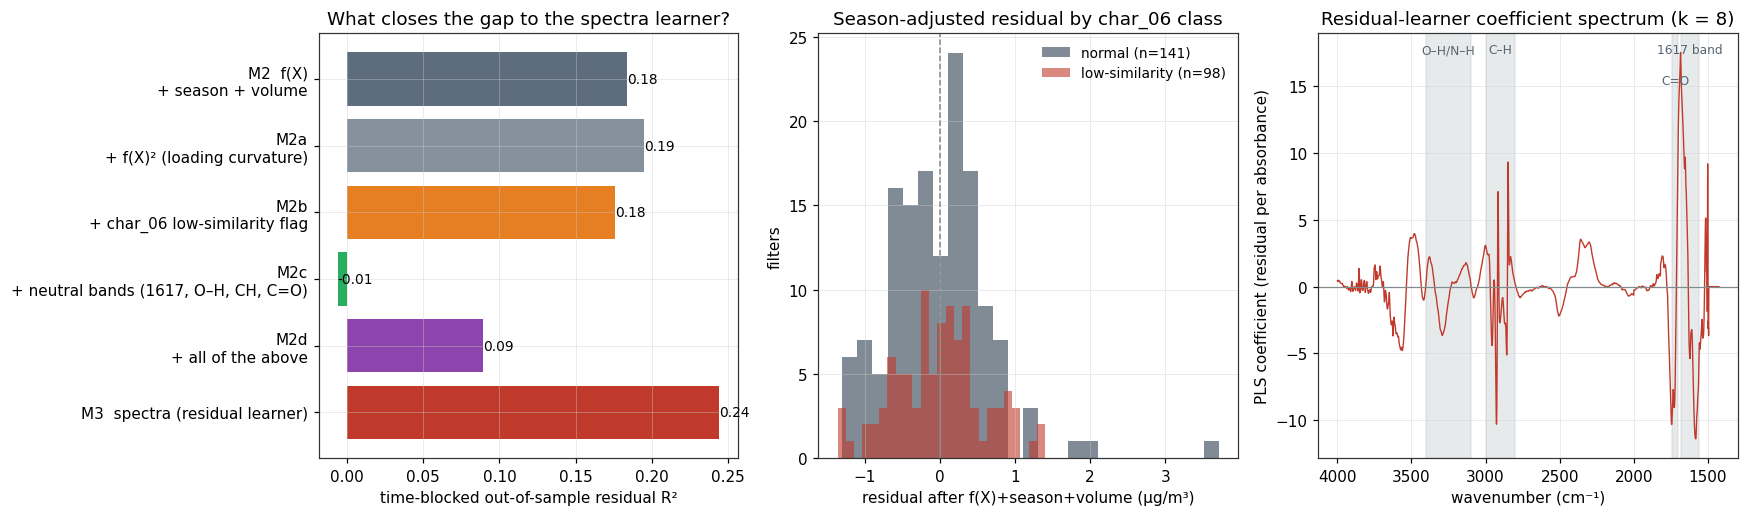

In [5]:
ks = np.arange(1, MAX_K + 1)
sse = np.zeros(MAX_K)
for g in range(N_BLOCKS):
    tr, te = block != g, block == g
    m = PLSRegression(n_components=MAX_K, scale=False).fit(X[tr], r[tr])
    sse += ((predict_pls_components(m, X[te], ks) - r[te][:, None]) ** 2).sum(axis=0)
k_full = int(ks[np.argmin(sse)])
full = PLSRegression(n_components=k_full, scale=False).fit(X, r)
coef = full.coef_.ravel()
coef_spectrum = pd.DataFrame({'wavenumber': wn_corr, 'coefficient': coef})
coef_spectrum.to_csv(OUT / 'residual_learner_coefficients.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ax = axes[0]
order = list(STEPS) + ['M3  spectra (residual learner)']
vals = results.set_index('model').loc[order, 'residual_R2']
colors = ['#5D6D7E', '#85929E', '#E67E22', '#27AE60', '#8E44AD', '#C0392B']
bars = ax.barh(range(len(order)), vals, color=colors)
for bar_, v in zip(bars, vals):
    ax.annotate(f'{v:.2f}', (v, bar_.get_y() + bar_.get_height() / 2), va='center', ha='left', fontsize=9)
ax.set(yticks=range(len(order)), yticklabels=[o.replace(' + ', '\n+ ', 1) for o in order],
       xlabel='time-blocked out-of-sample residual R²', title='What closes the gap to the spectra learner?')
ax.invert_yaxis()

ax = axes[1]
for cls, color in (('normal', '#2C3E50'), ('low-similarity', '#C0392B')):
    vals_c = by_class.loc[by_class['class'].eq(cls), 'season_adjusted_residual']
    ax.hist(vals_c, bins=25, alpha=0.6, color=color, label=f'{cls} (n={len(vals_c)})')
ax.axvline(0, color='#7F8C8D', lw=1, ls='--')
ax.set(xlabel='residual after f(X)+season+volume (µg/m³)', ylabel='filters',
       title='Season-adjusted residual by char_06 class')
ax.legend(frameon=False, fontsize=9)

ax = axes[2]
ax.plot(wn_corr, coef, color='#C0392B', lw=0.9)
ymax = ax.get_ylim()[1]
for lo, hi, label, level in ((1560, 1680, '1617 band', 0.92), (3100, 3400, 'O–H/N–H', 0.92),
                             (2800, 3000, 'C–H', 0.92), (1700, 1740, 'C=O', 0.80)):
    ax.axvspan(lo, hi, color='#BDC3C7', alpha=0.35)
    ax.annotate(label, ((lo + hi) / 2, ymax * level), ha='center', fontsize=8, color='#566573')
ax.axhline(0, color='#7F8C8D', lw=0.8)
ax.invert_xaxis()
ax.set(xlabel='wavenumber (cm⁻¹)', ylabel='PLS coefficient (residual per absorbance)',
       title=f'Residual-learner coefficient spectrum (k = {k_full})')
fig.tight_layout()
fig.savefig(PLOTS / 'residual_attribution.png', bbox_inches='tight')
plt.show()

## Takeaways

- **The dry-season anomaly does not explain the offset.** Low-similarity and normal
  filters have the same residual once season is in the model. The char_06 class is a
  spectral-shape observation, not a residual driver — retire "the char anomaly is the
  missing absorber" as a hypothesis for the *constant* offset.
- **Band heights are the wrong feature.** Scalar neutral-baseline amplitudes at the four
  canonical windows reduce out-of-sample skill; the learner's coefficients look like a
  derivative filter across 1560–1750 cm⁻¹. If anything spectral tracks the residual, it
  is where the 1617/carbonyl envelope sits and how sharp it is — ftir_12's peak-center
  diagnostic is the right instrument, applied to the residual rather than to site
  identity.
- **Loading is the lead, not the spectra.** f(X)² buys 0.01 here, and ftir_46 finds
  gravimetric mass predicts the residual as well as the full spectrum (mass + spectra
  R² 0.53, CI excluding zero) — consistent with ftir_37's loading-dependent HIPS
  mechanism. The spectral increment is not significant once metadata (incl. lot) is in
  the baseline.
- **Deployment reading unchanged from ftir_43**: the constant offset is the product; the
  residual learner is a diagnostic worth ≈0.03 µg/m³.
- Limits: linear stepwise models with 4–8 covariates on 239 filters; time-blocked
  folds are coarse; a PLS coefficient spectrum is not a chemical assignment.